# Load in NLR DB data for swift creek

In [50]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
def remove_header(df):
    """Deletes first row of df and sets column names to new first row
    """
    df = df[1:]
    df.columns = df.iloc[0]
    df = df[1:]
    return df

In [33]:
def drop_nan_columns(df):
    """Drops columns with all NaN values
    """
    df = df.dropna(axis=1, how='all')
    
    return df

In [34]:
def floatify_columns(df):
    # Convert all columns to float
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def rename_columns(df):
    map_name = {"Temperature": "Air Temperature"}
    # Map columns to new names
    df = df.rename(columns=map_name)
    return df

In [35]:
def load_one(file_path):
    df = pd.read_csv(file_path)
    df = remove_header(df)
    df = drop_nan_columns(df)
    df = floatify_columns(df)
    df = rename_columns(df)
    return df

In [36]:
def load_data(folder_path):
    dataframes = []
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = load_one(file_path)
            dataframes.append(df)
    # Concatenate all dataframes into one
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

In [38]:
df = load_data('data/NLRDB')

# Feature analysis

- Convert Wind Direction to a sinusoidal value (currently 0 to 360)

In [40]:
df.describe()

1,Year,Month,Day,Hour,Minute,Air Temperature,Alpha,Aerosol Optical Depth,Asymmetry,Clearsky DHI,...,GHI,Ozone,Relative Humidity,Solar Zenith Angle,SSA,Surface Albedo,Pressure,Precipitable Water,Wind Direction,Wind Speed
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.0,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,...,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000
mean,2021.500342,6.522930,15.729637,11.500000,0.0,21.305256,1.207004,0.147599,0.620931,52.897088,...,199.596680,0.285471,76.394229,89.723662,0.946350,0.156851,1012.018295,3.056751,161.997733,1.533629
std,2.291155,3.448728,8.800155,6.922236,0.0,8.913823,0.317478,0.101730,0.010397,64.231917,...,289.277795,0.020220,22.044780,40.878836,0.023918,0.027488,5.502232,1.421395,91.296021,1.058344
min,2018.000000,1.000000,1.000000,0.000000,0.0,-10.600000,0.060000,0.011000,0.600000,0.000000,...,0.000000,0.207000,12.390000,8.410000,0.830000,0.100000,992.000000,0.200000,0.000000,0.000000
25%,2020.000000,4.000000,8.000000,5.750000,0.0,15.300000,1.010000,0.078000,0.620000,0.000000,...,0.000000,0.272000,60.050000,55.600000,0.930000,0.150000,1008.000000,1.900000,106.000000,0.800000
50%,2021.500000,7.000000,16.000000,11.500000,0.0,22.700000,1.230000,0.125000,0.620000,0.000000,...,0.000000,0.286000,82.180000,89.180000,0.950000,0.160000,1011.000000,3.200000,158.000000,1.400000
75%,2024.000000,10.000000,23.000000,17.250000,0.0,27.300000,1.410000,0.188000,0.630000,102.000000,...,359.250000,0.299000,96.700000,123.710000,0.960000,0.160000,1015.000000,4.100000,199.000000,2.200000
max,2025.000000,12.000000,31.000000,23.000000,0.0,44.700000,2.230000,1.244000,0.640000,464.000000,...,1058.000000,0.390000,100.000000,172.200000,0.990000,0.800000,1037.000000,7.400000,360.000000,6.200000


In [44]:
df.isna().sum()

1
Year                     0
Month                    0
Day                      0
Hour                     0
Minute                   0
Air Temperature          0
Alpha                    0
Aerosol Optical Depth    0
Asymmetry                0
Clearsky DHI             0
Clearsky DNI             0
Clearsky GHI             0
Cloud Fill Flag          0
Cloud Type               0
Dew Point                0
DHI                      0
DNI                      0
Fill Flag                0
GHI                      0
Ozone                    0
Relative Humidity        0
Solar Zenith Angle       0
SSA                      0
Surface Albedo           0
Pressure                 0
Precipitable Water       0
Wind Direction           0
Wind Speed               0
dtype: int64

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   70128 non-null  int64  
 1   Month                  70128 non-null  int64  
 2   Day                    70128 non-null  int64  
 3   Hour                   70128 non-null  int64  
 4   Minute                 70128 non-null  int64  
 5   Air Temperature        70128 non-null  float64
 6   Alpha                  70128 non-null  float64
 7   Aerosol Optical Depth  70128 non-null  float64
 8   Asymmetry              70128 non-null  float64
 9   Clearsky DHI           70128 non-null  int64  
 10  Clearsky DNI           70128 non-null  int64  
 11  Clearsky GHI           70128 non-null  int64  
 12  Cloud Fill Flag        70128 non-null  int64  
 13  Cloud Type             70128 non-null  int64  
 14  Dew Point              70128 non-null  float64
 15  DHI          

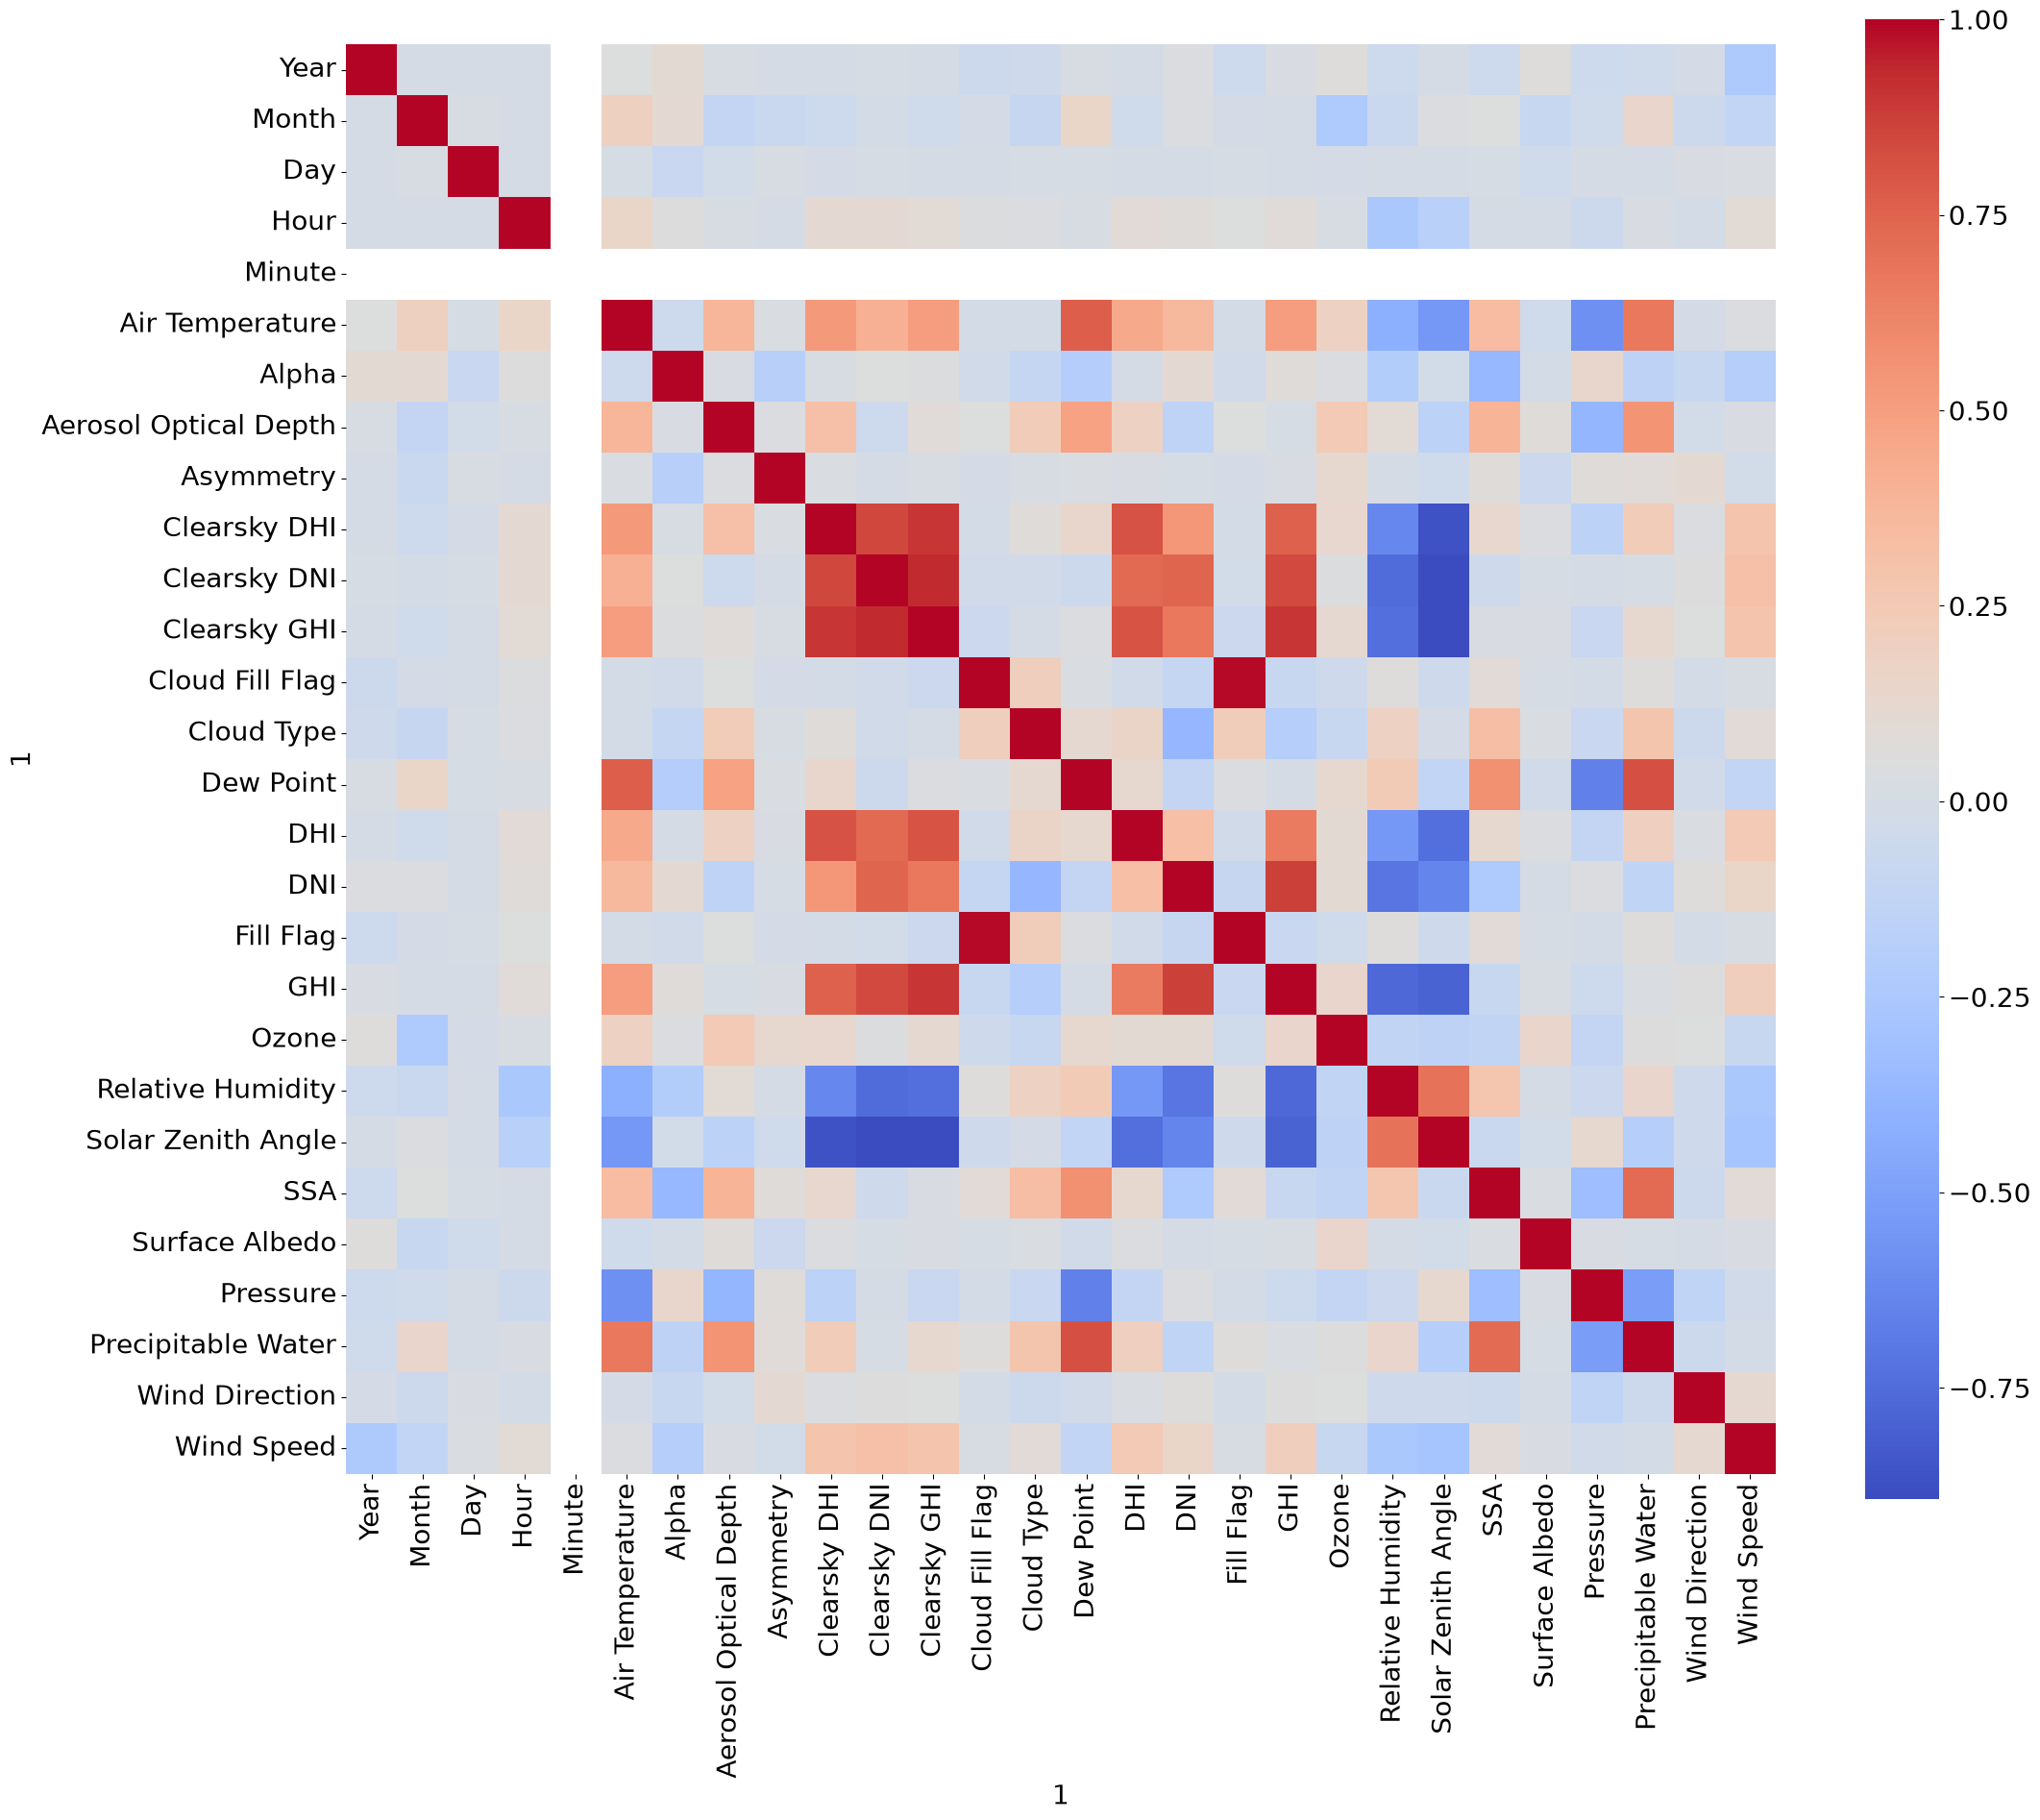

In [53]:
fig, ax = plt.subplots(figsize=(24,20))
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
#num_cols = num_cols.append(merged.columns[-1:])
corr = df[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=False, cmap="coolwarm",ax=ax)
ax.set_aspect(1)